<a href="https://colab.research.google.com/github/PioBasile/Classification-tweet-scientifique/blob/main/ProjetMachineLearning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
# Importation des librairies utilisées dans le notebook

# Masque les FutureWarning de scikit-learn
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

# Librairies générales
import pandas as pd          # Manipulation de tableaux
import numpy as np           # Calcul numérique
import string                # Gestion de chaînes
import re                    # Expressions régulières
import unicodedata           # Normalisation Unicode
#import contractions          # Gestion des contractions
from collections import Counter  # Comptage d'occurrences
from wordcloud import WordCloud         # Generation de nuages de mots

# Nettoyage de texte HTML
from bs4 import BeautifulSoup    # Parsing HTML

# Librairies d'affichage
import matplotlib.pyplot as plt  # Graphiques statiques
import plotly.graph_objs as go   # Graphiques avancés Plotly
import plotly.offline as py      # Mode offline Plotly
import plotly.express as px      # Visualisation rapide
import plotly.io as pio          # Sauvegarde d'images


# Librairies NLTK
import nltk                      # NLP basique
from nltk import sent_tokenize   # Découpage en phrases
from nltk import word_tokenize   # Découpage en mots
from nltk import pos_tag         # Étiquetage grammatical
from nltk.stem import WordNetLemmatizer   # Lemmatisation
from nltk.stem.snowball import SnowballStemmer   # Stemmatisation
from nltk.corpus import stopwords          # Stopwords

# Téléchargement des ressources NLTK
nltk.download("punkt")                      # Tokenisation
nltk.download("punkt_tab")                  # Tokenisation
nltk.download("averaged_perceptron_tagger") # Tags
nltk.download("averaged_perceptron_tagger_eng")  # Tags anglais
nltk.download("tagsets_json")               # Liste des tags
nltk.download("tagsets")                    # Ancienne liste
nltk.download("stopwords")                  # Stopwords
nltk.download("wordnet")                    # WordNet

# NLP avec SpaCy
import spacy                                # NLP avancé
from spacy import displacy                  # Visualisation
from spacy.lang.fr import French            # Modèle français

# Chargement du modèle anglais
nlp = spacy.load("en_core_web_sm")          # Modèle anglais

#Pour les comparaisons
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report

#equilibrage et split
from imblearn.over_sampling import RandomOverSampler
from sklearn.model_selection import train_test_split


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package tagsets_json to /root/nltk_data...
[nltk_data]   Package tagsets_json is already up-to-date!
[nltk_data] Downloading package tagsets to /root/nltk_data...
[nltk_data]   Package tagsets is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading pac

In [3]:
from google.colab import drive
import pandas as pd
import re
import spacy
"""
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

# Téléchargement des ressources NLTK nécessaires
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
"""

drive.mount('/content/drive')
path = '/content/drive/MyDrive/ColabNotebooks/scitweets_export.tsv'

Mounted at /content/drive


# Clean les Tweets

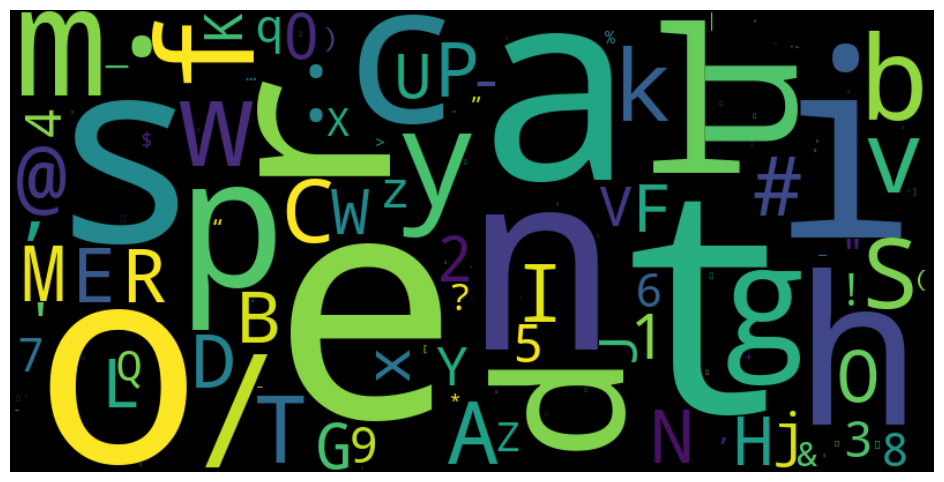

In [4]:
df = pd.read_csv(path, sep='\t')

all_words = df['text']
words = [word for sublist in all_words for word in sublist]

word_counts = Counter(words)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud.png")

Resultat avant le pretraitement

In [5]:
df = pd.read_csv(path, sep='\t')

#traitement des émoticones
emoticons_str = r"""
    (?:
        [:=;] # Eyes
        [oO\-]? # Nose (optional)
        [D\)\]\(\]/\\OpP] # Mouth
    )"""

#Prise en compte des éléments qui doivent être regroupés
regex_str = [
    emoticons_str,
    r'<[^>]+>', # HTML tags
    r'(?:@[\w_]+)', # @-mentions
    r"(?:\#+[\w_]+[\w\'_\-]*[\w_]+)", # hash-tags
    r'http[s]?://(?:[a-z]|[0-9]|[$-_@.&amp;+]|[!*\(\),]|(?:%[0-9a-f][0-9a-f]))+', # URLs

    r'(?:(?:\d+,?)+(?:\.?\d+)?)', # nombres
    r"(?:[a-z][a-z'\-_]+[a-z])", # mots avec - et '
    r'(?:[\w_]+)', # autres mots
    r'(?:\S)' # le reste
]

tokens_re = re.compile(r'('+'|'.join(regex_str)+')', re.VERBOSE | re.IGNORECASE)
emoticon_re = re.compile(r'^'+emoticons_str+'$', re.VERBOSE | re.IGNORECASE)

def tokenize(s):
    return tokens_re.findall(s)

def preprocess(s, lowercase=False):
    tokens = tokenize(s)
    if lowercase:
        tokens = [
            tok if emoticon_re.search(tok) else tok.lower()
            for tok in tokens
        ]
    return tokens


In [6]:
contractions_map = {
    "don't": "do not",
    "doesn't": "does not",
    "can't": "cannot",
    "won't": "will not",
    "i'm": "i am",
    "it's": "it is",
    "you're": "you are",
    "they're": "they are",
    "we're": "we are",
}

def expand_contractions(text):
    # Normalisation simple des apostrophes typographiques
    text = text.replace("’", "'")
    tokens = text.split()
    expanded = []
    for t in tokens:
        key = t.lower()
        if key in contractions_map:
            expanded.extend(contractions_map[key].split())
        else:
            expanded.append(t)
    return " ".join(expanded)


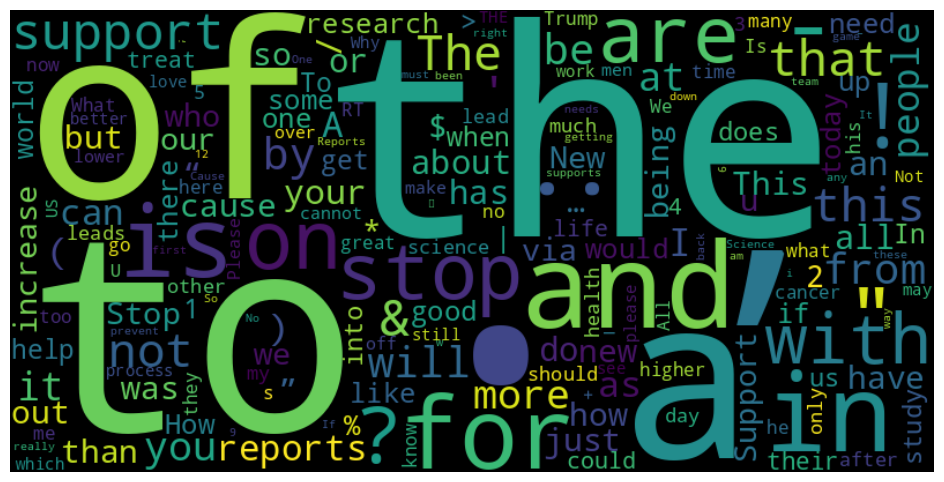

In [7]:
df['text_expanded'] = df['text'].apply(expand_contractions)
all_words_processed = df['text_expanded'].apply(preprocess)
words = [word for sublist in all_words_processed for word in sublist]

word_counts = Counter(words)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()

wc.to_file("wordcloud2.png")


# Prétraitement

### Sac de mots

In [63]:
from sklearn.feature_extraction.text import CountVectorizer


#Code du cours
vectorizer = CountVectorizer(lowercase=False, stop_words="english", min_df=2, max_df=0.8, ngram_range=(1,1))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#lowercase=False: Ne convertit pas en minuscules (respecte la casse).
#stop_words="english": Supprime les mots courants anglais (mots vides).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#ngram_range=(1,1): N'extrait que des mots uniques (unigrammes).

METHODE = "SAC DE MOTS"


['Indonesia' 'Industry' 'Instead' 'Institute' 'Interesting'
 'International' 'Iran' 'Is' 'Islam' 'Israel']
(1140, 1905)


##Pondération des mots

In [70]:
from sklearn.feature_extraction.text import TfidfVectorizer



#Code du cours
vectorizer = TfidfVectorizer(norm="l2",sublinear_tf=True,min_df=2, max_df=0.8, max_features=5000,ngram_range=(1,2))
X = vectorizer.fit_transform(df["text"])

vocabulaire = vectorizer.get_feature_names_out()
print(vocabulaire[300:310])

print(X.shape)

#norm="l2": Applique une normalisation L2 aux vecteurs TF-IDF.
#sublinear_tf=True: Applique une mise à l'échelle sous-linéaire à la fréquence des termes (1 + log(tf)).
#min_df=2: Ignore les mots apparaissant dans moins de 2 documents.
#max_df=0.8: Ignore les mots apparaissant dans plus de 80% des documents.
#max_features=5000: Limite le vocabulaire aux 5000 termes les plus fréquents.
#ngram_range=(1,2): Extrait des mots seuls (unigrammes) et des paires de mots (bigrammes).

METHODE = "PONDERATION"

['be using' 'be very' 'beaten' 'beaten by' 'beautiful' 'beauty' 'because'
 'because of' 'become' 'becomes']
(1140, 3129)


## Visuel Pretraitement

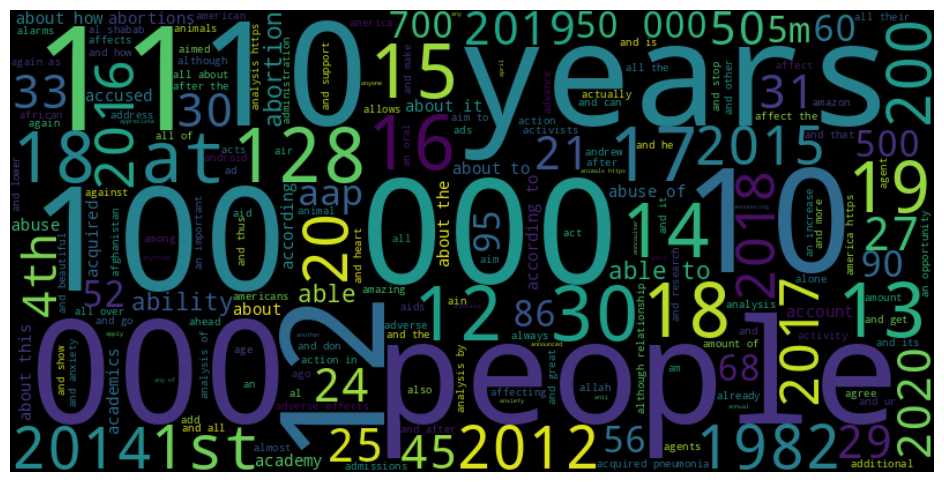

Wordcloud pour la methode : PONDERATION


In [60]:
word_counts = Counter(vocabulaire)

wc = WordCloud(width=800, height=400)         # Creation du word cloud
wc.generate_from_frequencies(word_counts)     # Generation

plt.figure(figsize=(12, 6))                   # Affichage
plt.imshow(wc, interpolation="bilinear")
plt.axis("off")
plt.show()


wc.to_file("wordcloud2.png")
print("Wordcloud pour la methode : " + METHODE)

# SCI vs NON-SCI


## Equilibrage

In [44]:

y = df["science_related"].values

#avant
unique_avant, counts_avant = np.unique(y, return_counts=True)
axes[0].bar(["NON-SCI", "SCI"], counts_avant, color=["#5DCAA5", "#7F77DD"])
axes[0].set_title("Avant rééquilibrage")
axes[0].set_ylabel("Nombre d'exemples")
for i, v in enumerate(counts_avant):
    axes[0].text(i, v + 10, str(v), ha="center", fontweight="bold")

# Rééquilibrage
ros = RandomOverSampler(random_state=42)
X_res, y_res = ros.fit_resample(X, y)

#après
unique_apres, counts_apres = np.unique(y_res, return_counts=True)
axes[1].bar(["NON-SCI", "SCI"], counts_apres, color=["#5DCAA5", "#7F77DD"])
axes[1].set_title("Après rééquilibrage")
for i, v in enumerate(counts_apres):
    axes[1].text(i, v + 10, str(v), ha="center", fontweight="bold")


## Division de la data pour les tests


In [51]:
Y = df[['science_related']]
print(Y.head())

X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("Variable entrainement:", X_train.shape)
print("Variable tests:", X_test.shape)
print("Variable entrainement resultat:", y_train.shape)
print("Variable entrainement resultat des tests:", y_test.shape)

   science_related
0                0
1                0
2                1
3                1
4                1
Variable entrainement: (1224, 3129)
Variable tests: (306, 3129)
Variable entrainement resultat: (1224,)
Variable entrainement resultat des tests: (306,)


## Classifieur


In [67]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Decision Tree":   DecisionTreeClassifier(random_state=42),
    "Naive Bayes":     MultinomialNB(),
    "SVM":    LinearSVC(random_state=42, max_iter=2000),
    "Random Forest":   RandomForestClassifier(n_estimators=100, random_state=42),
    "KNN":             KNeighborsClassifier(n_neighbors=5),
}


### Models


In [71]:
results_t1 = {}

for name, clf in models.items():
    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    report = classification_report(y_test, y_pred, output_dict=True)
    results_t1[name] = {
        "accuracy":  report["accuracy"],
        "f1_macro":  report["macro avg"]["f1-score"],
        "precision": report["macro avg"]["precision"],
        "recall":    report["macro avg"]["recall"],
    }

df_results = pd.DataFrame(results_t1).T.sort_values("f1_macro", ascending=False)
print(df_results.round(3).to_string())

# Meilleur modèle
best_name = df_results.index[0]
best_model = models[best_name]
print(f"\nMeilleur modèle : {best_name} (F1 macro = {df_results.loc[best_name, 'f1_macro']:.3f}) en utilisant : {METHODE}")

#Le f1 macro c'est pour voir si le model renvoie juste pas la meme chose en boucle et a de la chance



               accuracy  f1_macro  precision  recall
SVM               0.899     0.899      0.899   0.899
Random Forest     0.892     0.892      0.893   0.892
Naive Bayes       0.882     0.882      0.883   0.882
Decision Tree     0.817     0.816      0.821   0.817
KNN               0.739     0.737      0.743   0.739

Meilleur modèle : SVM (F1 macro = 0.899) en utilisant : PONDERATION
